In [18]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Configuration ────────────────────────────────────────────────────────────
vocab        = ["aardvark", "...", "dinner", "dog", "dune", "...", "zyzzyva"]
ellipsis_idx = {1, 5}   # positions shown as "…" – no bar drawn
target_idx   = 3        # index of the correct next word ("dog")

# Logits for the real words; ellipsis slots are masked out
logits_raw = np.array([0.5, 0.0, 1.1, 2.1, 0.9, 0.0, 0.3])
mask  = np.array([0.0 if i in ellipsis_idx else 1.0 for i in range(len(vocab))])
exp_l = np.exp(logits_raw) * mask
probs = exp_l / exp_l.sum()       # ellipsis slots → 0, rest sums to 1

gt = np.zeros(len(vocab)); gt[target_idx] = 1.0

# ── Shared style ─────────────────────────────────────────────────────────────
COLOR_TEAL  = "#1a6b6b"
COLOR_GREY  = "#4a4a4a"
COLOR_ARROW = "#cc2222"

BAR_WIDTH = 0.55
FIG_SIZE  = (4.5, 3.2)

def _base_ax(fig):
    fig.patch.set_facecolor("#f5f5f5")
    ax = fig.add_subplot(111)
    ax.set_facecolor("#f5f5f5")
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
    ax.tick_params(bottom=False, left=False)
    ax.set_xticks(range(len(vocab)))
    ax.set_xticklabels(vocab, fontsize=10)
    ax.set_yticks([])
    ax.grid(False)
    # Style the ellipsis tick labels
    for lbl, word in zip(ax.get_xticklabels(), vocab):
        if word == "...":
            lbl.set_color("#aaaaaa")
            lbl.set_fontsize(13)
    return ax

print(f"Target word : '{vocab[target_idx]}'")
print(f"Probabilities: {dict(zip(vocab, probs.round(3)))}")
print(f"p(target)   = {probs[target_idx]:.4f}   cross-entropy loss = {-np.log(probs[target_idx]):.4f}")


Target word : 'dog'
Probabilities: {'aardvark': np.float64(0.099), '...': np.float64(0.0), 'dinner': np.float64(0.181), 'dog': np.float64(0.491), 'dune': np.float64(0.148), 'zyzzyva': np.float64(0.081)}
p(target)   = 0.4911   cross-entropy loss = 0.7111


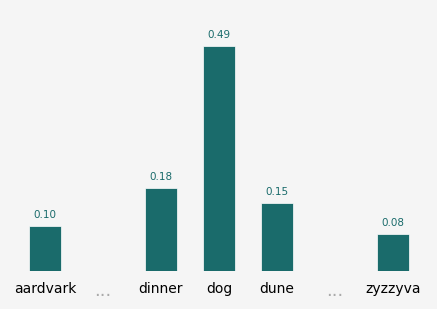

In [19]:

# ── Figure 1 : Model predictions ─────────────────────────────────────────────
fig1 = plt.figure(figsize=FIG_SIZE)
ax1  = _base_ax(fig1)

bars = ax1.bar(range(len(vocab)), probs,
               width=BAR_WIDTH, color=COLOR_TEAL,
               edgecolor="white", linewidth=0.5, zorder=3)

# probability labels above each bar (skip ellipsis slots)
for i, (bar, p) in enumerate(zip(bars, probs)):
    if i in ellipsis_idx:
        continue
    ax1.text(bar.get_x() + bar.get_width() / 2, p + 0.015,
             f"{p:.2f}", va="bottom", ha="center", fontsize=7.5, color=COLOR_TEAL)

ax1.set_ylim(0, max(probs) + 0.08)

fig1.tight_layout()
plt.savefig("../slides/img/lecture03/cross_entropy_model.svg", bbox_inches="tight")
plt.show()


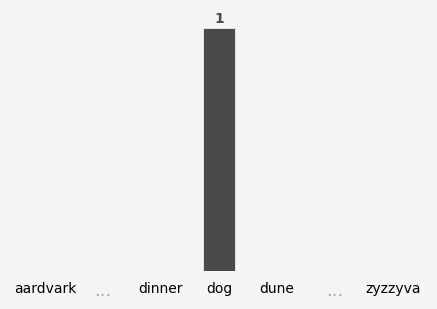

In [20]:

# ── Figure 2 : Ground-truth distribution ─────────────────────────────────────
fig2 = plt.figure(figsize=FIG_SIZE)
ax2  = _base_ax(fig2)

ax2.bar(range(len(vocab)), gt,
        width=BAR_WIDTH, color=COLOR_GREY,
        edgecolor="white", linewidth=0.5, zorder=3)

# label only the target bar
ax2.text(target_idx, gt[target_idx] + 0.015,
         "1", va="bottom", ha="center", fontsize=10, color=COLOR_GREY, fontweight="bold")

ax2.set_ylim(0, max(gt) + 0.08)

fig2.tight_layout()
plt.savefig("../slides/img/lecture03/cross_entropy_gt.svg", bbox_inches="tight")
plt.show()


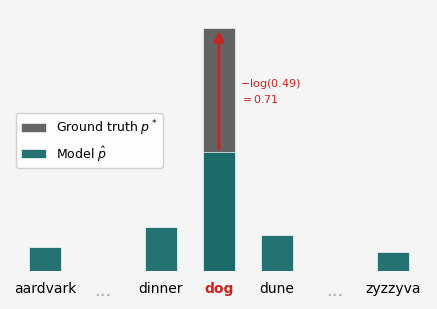

In [21]:

# ── Figure 3 : Overlay with cross-entropy annotation ─────────────────────────
fig3 = plt.figure(figsize=FIG_SIZE)
ax3  = _base_ax(fig3)

# Ground-truth bars (behind)
ax3.bar(range(len(vocab)), gt,
        width=BAR_WIDTH, color=COLOR_GREY, alpha=0.85,
        edgecolor="white", linewidth=0.5, zorder=2,
        label="Ground truth $p^*$")

# Model prediction bars (in front)
ax3.bar(range(len(vocab)), probs,
        width=BAR_WIDTH, color=COLOR_TEAL, alpha=0.95,
        edgecolor="white", linewidth=0.5, zorder=3,
        label="Model $\\hat{p}$")

# ── Red arrow: top of model's target bar → ground-truth value (1.0) ──────────
p_target = probs[target_idx]
x_target = target_idx

ax3.annotate(
    "",
    xy     =(x_target, 1.0),
    xytext =(x_target, p_target),
    arrowprops=dict(
        arrowstyle="-|>",
        color=COLOR_ARROW,
        lw=2.0,
        mutation_scale=14,
    ),
    zorder=5,
)

# Loss label beside the arrow
loss_val = -np.log(p_target)
mid_y    = (p_target + 1.0) / 2
ax3.text(x_target + BAR_WIDTH / 2 + 0.08, mid_y,
         f"$-\\log({p_target:.2f})$\n$= {loss_val:.2f}$",
         ha="left", va="center", fontsize=8,
         color=COLOR_ARROW, zorder=6)

# Highlight target word label in red
for i, lbl in enumerate(ax3.get_xticklabels()):
    if i == target_idx:
        lbl.set_color(COLOR_ARROW)
        lbl.set_fontweight("bold")

ax3.set_ylim(0, max(gt) + 0.08)
ax3.legend(loc="center left", fontsize=9, framealpha=0.9)

fig3.tight_layout()
plt.savefig("../slides/img/lecture03/cross_entropy_overlay.svg", bbox_inches="tight")
plt.show()
